# Modeling Phase 1: DistilBERT Fine-Tuning with GPU Acceleration

**Task:** Multi-class geek type classification on Board Game descriptions

## Execution Order:
1. Load data & dependencies
2. Prepare labels & splits
3. Create TF-IDF baseline
4. Setup DistilBERT model
5. Train with GPU (10 epochs)
6. Evaluate & visualize
7. Save artifacts

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from itertools import chain
import warnings
warnings.filterwarnings("ignore")

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)

# === Load Main Dataset ===
# Check environment (local vs Colab)
import sys

if 'google.colab' in sys.modules:
    # Colab environment - mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = Path('/content/drive/My Drive/Notebooks Tese/Dataset')
else:
    # Local environment
    DATA_DIR = Path("../Dataset/XML Dataset")

print(f" Data directory: {DATA_DIR}")
print(f"   Exists: {DATA_DIR.exists()}")

# Load geek_type subset from EDA
try:
    df_type = pd.read_parquet(DATA_DIR / "bgg_geektype_subset.parquet")
except FileNotFoundError:
    print(f" File not found at {DATA_DIR / 'bgg_geektype_subset.parquet'}")
    print(f"   Available files in {DATA_DIR}:")
    if DATA_DIR.exists():
        for f in DATA_DIR.glob("*.parquet"):
            print(f"   - {f.name}")
    raise

print(" Geek Type subset loaded")
print(f"  Shape: {df_type.shape}")
print(f"  Columns: {df_type.columns.tolist()}")
print(f"\n  Sample row:")
print(df_type[["id", "name", "description_clean", "geek_type_list"]].iloc[0])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Data directory: /content/drive/My Drive/Notebooks Tese/Dataset
   Exists: True
 Geek Type subset loaded
  Shape: (14713, 4)
  Columns: ['id', 'name', 'description_clean', 'geek_type_list']

  Sample row:
id                                                              224517
name                                                 Brass: Birmingham
description_clean    brass birmingham economic strategy sequel mart...
geek_type_list                                              [Strategy]
Name: 0, dtype: object


## Step 2: Prepare Labels (Single-Label Multi-Class Encoding)


In [2]:
from sklearn.preprocessing import LabelEncoder

# Get all unique geek types
all_geek_types = sorted(set(chain.from_iterable(df_type['geek_type_list'])))
print(f'Unique geek types: {all_geek_types}')
print(f'Number of classes: {len(all_geek_types)}\n')

# Extract single label per game (geek_type_list has exactly 1 element each)
y_labels = df_type['geek_type_list'].apply(lambda x: x[0]).values  # Get first (only) element

print(f'Sample labels (first 10):')
print(y_labels[:10])
print(f'\nLabel distribution (count):')
y_series = pd.Series(y_labels)
print(y_series.value_counts().sort_index())

# Encode as class indices (0-7)
le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)

print(f'\nClass index mapping:')
for i, label in enumerate(le.classes_):
    print(f'  {i}: {label}')

# Store for later use
label_names = le.classes_
num_labels = len(label_names)
class_to_idx = {label: idx for idx, label in enumerate(label_names)}
idx_to_class = {idx: label for idx, label in enumerate(label_names)}

print(f'\nLabels prepared: {num_labels} classes')
print(f'  Shape: ({len(y_encoded)},)  [class indices]')

Unique geek types: ['Abstract', 'Cgs', "Children's", 'Family', 'Party', 'Strategy', 'Thematic', 'War']
Number of classes: 8

Sample labels (first 10):
['Strategy' 'Thematic' 'Strategy' 'Thematic' 'Thematic' 'Strategy'
 'Strategy' 'War' 'Thematic' 'Strategy']

Label distribution (count):
Abstract      1446
Cgs            369
Children's    1099
Family        2867
Party          944
Strategy      2180
Thematic      1589
War           4219
Name: count, dtype: int64

Class index mapping:
  0: Abstract
  1: Cgs
  2: Children's
  3: Family
  4: Party
  5: Strategy
  6: Thematic
  7: War

Labels prepared: 8 classes
  Shape: (14713,)  [class indices]


## Step 3: Stratified Train/Val/Test Split
### Single-label stratification (straightforward with sklearn)

In [3]:
from sklearn.model_selection import train_test_split

# Prepare data
X = df_type[['id', 'name', 'description_clean']].reset_index(drop=True)
y = y_encoded  # Class indices (shape: 14713,)

print('Before split:')
print(f'  Total samples: {len(X)}')
print(f'  y shape: {y.shape}')
print(f'  y dtype: {y.dtype}')

# Split 1: Train (70%) vs temp (30%)
# Stratify by y directly (single class label per sample)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

print(f'\nAfter train/temp split:')
print(f'  Train: {len(X_train)} samples')
print(f'  Temp: {len(X_temp)} samples')
print(f'  y_train shape: {y_train.shape}, y_temp shape: {y_temp.shape}')

# Split 2: Val (50%) vs test (50%) from temp
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f'\nAfter val/test split:')
print(f'  Val: {len(X_val)} samples')
print(f'  Test: {len(X_test)} samples')
print(f'  y_val shape: {y_val.shape}, y_test shape: {y_test.shape}')

# Reset indices on DataFrames for cleaner indexing
X_train_df = X_train.reset_index(drop=True)
X_val_df = X_val.reset_index(drop=True)
X_test_df = X_test.reset_index(drop=True)

print(f'\nFinal splits prepared:')
print(f'  X_train_df: {X_train_df.shape}')
print(f'  X_val_df: {X_val_df.shape}')
print(f'  X_test_df: {X_test_df.shape}')

print(f'\nFinal split ratios:')
print(f'  Train: {len(X_train_df) / len(X):.1%}')
print(f'  Val:   {len(X_val_df) / len(X):.1%}')
print(f'  Test:  {len(X_test_df) / len(X):.1%}')

print('\nStratified split completed (single-label stratification)')

Before split:
  Total samples: 14713
  y shape: (14713,)
  y dtype: int64

After train/temp split:
  Train: 10299 samples
  Temp: 4414 samples
  y_train shape: (10299,), y_temp shape: (4414,)

After val/test split:
  Val: 2207 samples
  Test: 2207 samples
  y_val shape: (2207,), y_test shape: (2207,)

Final splits prepared:
  X_train_df: (10299, 3)
  X_val_df: (2207, 3)
  X_test_df: (2207, 3)

Final split ratios:
  Train: 70.0%
  Val:   15.0%
  Test:  15.0%

Stratified split completed (single-label stratification)


## Step 4: Verify Stratification
### RED FLAG Check: Label distributions must match across splits (max diff < 2%)

In [4]:
# Compute class distributions for each split
train_dist = np.bincount(y_train, minlength=num_labels) / len(y_train)
val_dist = np.bincount(y_val, minlength=num_labels) / len(y_val)
test_dist = np.bincount(y_test, minlength=num_labels) / len(y_test)

# Compute max differences
max_diff_val = np.abs(train_dist - val_dist).max()
max_diff_test = np.abs(train_dist - test_dist).max()

print('=== Stratification Verification ===\n')
print(f'Max distribution difference (train vs val): {max_diff_val:.4f}')
print(f'Max distribution difference (train vs test): {max_diff_test:.4f}')

if max_diff_val > 0.02 or max_diff_test > 0.02:
    print('\n  WARNING: Splits may not be properly stratified!')
else:
    print('\nSplits are properly stratified (<2% difference)')

# Show detailed distributions
print('\n=== Class Distribution by Split ===')
dist_summary = pd.DataFrame({
    'Train %': train_dist * 100,
    'Val %': val_dist * 100,
    'Test %': test_dist * 100,
}, index=label_names)
print(dist_summary.round(2))

# Count samples per class per split
print('\n=== Sample Count per Class ===')
sample_counts = pd.DataFrame({
    'Train': np.bincount(y_train, minlength=num_labels),
    'Val': np.bincount(y_val, minlength=num_labels),
    'Test': np.bincount(y_test, minlength=num_labels),
}, index=label_names)
print(sample_counts)

print('\nStratification verification complete')

=== Stratification Verification ===

Max distribution difference (train vs val): 0.0003
Max distribution difference (train vs test): 0.0002

Splits are properly stratified (<2% difference)

=== Class Distribution by Split ===
            Train %  Val %  Test %
Abstract       9.83   9.83    9.83
Cgs            2.51   2.49    2.49
Children's     7.47   7.48    7.48
Family        19.49  19.48   19.48
Party          6.42   6.39    6.43
Strategy      14.82  14.82   14.82
Thematic      10.80  10.83   10.78
War           28.67  28.68   28.68

=== Sample Count per Class ===
            Train  Val  Test
Abstract     1012  217   217
Cgs           259   55    55
Children's    769  165   165
Family       2007  430   430
Party         661  141   142
Strategy     1526  327   327
Thematic     1112  239   238
War          2953  633   633

Stratification verification complete


## Step 5: TF-IDF + Logistic Regression Baseline
### Classical baseline for performance comparison

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

print('=== TF-IDF + Logistic Regression Baseline ===\n')

# Vectorize text
print('Vectorizing text...')
vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=5)
X_train_tfidf = vectorizer.fit_transform(X_train_df['description_clean'].values)
X_val_tfidf = vectorizer.transform(X_val_df['description_clean'].values)
X_test_tfidf = vectorizer.transform(X_test_df['description_clean'].values)

print(f'TF-IDF shape: {X_train_tfidf.shape}')

# Train Logistic Regression
print('\nTraining Logistic Regression...')
lr_model = LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=SEED)
lr_model.fit(X_train_tfidf, y_train)

# Evaluate
y_val_pred = lr_model.predict(X_val_tfidf)
val_acc = accuracy_score(y_val, y_val_pred)
val_f1_macro = f1_score(y_val, y_val_pred, average='macro')

print(f'\n=== Validation Performance ===')
print(f'Accuracy: {val_acc:.4f}')
print(f'F1 (macro): {val_f1_macro:.4f}')

# Store baseline results
tfidf_val_acc = val_acc
tfidf_val_f1 = val_f1_macro

print('\nTF-IDF baseline complete')

=== TF-IDF + Logistic Regression Baseline ===

Vectorizing text...
TF-IDF shape: (10299, 3000)

Training Logistic Regression...

=== Validation Performance ===
Accuracy: 0.7213
F1 (macro): 0.6684

TF-IDF baseline complete


## Step 6: BERT Single-Label Model Setup
### Multi-class single-label transformer (CrossEntropyLoss, Softmax)

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau
import torch.cuda as cuda

# Detect GPU (Colab environment)
device = torch.device('cuda' if cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'   GPU: {cuda.get_device_name(0)}')
    print(f'   Memory: {cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')
print()

# Load DistilBERT tokenizer (faster & more efficient than BERT)
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

# Custom Dataset class with preprocessing
class SingleLabelDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts.iloc[idx])
        label = self.labels[idx]
        
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(label, dtype=torch.long)
        }

# Create datasets with optimized parameters
train_dataset = SingleLabelDataset(X_train_df['description_clean'], y_train, tokenizer, max_len=256)
val_dataset = SingleLabelDataset(X_val_df['description_clean'], y_val, tokenizer, max_len=256)

# Create dataloaders with better batch size for GPU
batch_size = 32  # Larger batch size for GPU acceleration
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True if device.type == 'cuda' else False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, num_workers=0, pin_memory=True if device.type == 'cuda' else False)

print(f'Datasets created:')
print(f'   Train: {len(train_dataset)} samples, {len(train_loader)} batches')
print(f'   Val: {len(val_dataset)} samples, {len(val_loader)} batches')
print(f'   Batch size: {batch_size}')
print(f'\nDatasets and DataLoaders ready for GPU training')

Device: cuda
   GPU: Tesla T4
   Memory: 14.6 GB



config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Datasets created:
   Train: 10299 samples, 322 batches
   Val: 2207 samples, 69 batches
   Batch size: 32

Datasets and DataLoaders ready for GPU training


## Step 6b: BERT Single-Label Model Definition
### Model architecture: BERT + classification head with CrossEntropyLoss

In [7]:
# DistilBERT-based architecture for single-label classification
class DistilBERTSingleLabel(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.2):
        super().__init__()
        # DistilBERT: smaller, faster, 40% lighter than BERT-base
        self.distilbert = AutoModel.from_pretrained('distilbert-base-uncased')
        
        # Linear projection layer
        self.pre_classifier = nn.Linear(self.distilbert.config.hidden_size, self.distilbert.config.hidden_size)
        self.dropout = nn.Dropout(dropout_rate)
        
        # Classification head
        self.classifier = nn.Linear(self.distilbert.config.hidden_size, num_classes)
        
        # ReLU activation
        self.relu = nn.ReLU()
    
    def forward(self, input_ids, attention_mask):
        # DistilBERT encoding
        outputs = self.distilbert(input_ids=input_ids, attention_mask=attention_mask)
        
        # Use [CLS] token representation (first token)
        hidden_state = outputs.last_hidden_state
        pooled = hidden_state[:, 0]  # Extract [CLS] token
        
        # Pre-classification layers
        pooled = self.relu(self.pre_classifier(pooled))
        pooled = self.dropout(pooled)
        
        # Classification logits
        logits = self.classifier(pooled)
        
        return logits

# Initialize model
model = DistilBERTSingleLabel(num_classes=num_labels, dropout_rate=0.2).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Model Architecture: DistilBERT + Classification Head')
print(f'   Hidden size: {model.distilbert.config.hidden_size}')
print(f'   Num classes: {num_labels}')
print(f'   Dropout: 0.2')
print(f'   Total parameters: {total_params:,}')
print(f'   Trainable parameters: {trainable_params:,}')
print(f'\nTraining Configuration:')

# Loss function: CrossEntropyLoss (for single-label multi-class)
criterion = nn.CrossEntropyLoss(reduction='mean')

# Optimizer with weight decay for regularization
optimizer = optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

# Learning rate scheduler: cosine annealing
num_training_steps = len(train_loader) * 5  # 5 epochs
scheduler = CosineAnnealingLR(optimizer, T_max=num_training_steps, eta_min=1e-6)

print(f'   Loss: CrossEntropyLoss')
print(f'   Optimizer: AdamW (lr=2e-5, weight_decay=0.01)')
print(f'   Scheduler: CosineAnnealingLR (T_max={num_training_steps})')
print(f'   Device: {device}')
print(f'\nModel initialized on {device}')

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model Architecture: DistilBERT + Classification Head
   Hidden size: 768
   Num classes: 8
   Dropout: 0.2
   Total parameters: 66,959,624
   Trainable parameters: 66,959,624

Training Configuration:
   Loss: CrossEntropyLoss
   Optimizer: AdamW (lr=2e-5, weight_decay=0.01)
   Scheduler: CosineAnnealingLR (T_max=1610)
   Device: cuda

Model initialized on cuda


## Step 7: BERT Training Loop
### Train BERT model with evaluation on validation set

In [8]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import time

def evaluate(model, dataloader, device, criterion):
    """Evaluate model on a dataset"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            
            total_loss += loss.item()
            
            # Get predictions
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    
    return avg_loss, accuracy, f1_macro, precision, recall

# Training configuration
num_epochs = 10
patience = 3
best_val_f1 = 0
patience_counter = 0
all_train_losses = []
all_val_losses = []
all_val_f1s = []

print('='*80)
print('DISTILBERT FINE-TUNING: 10 EPOCHS WITH EARLY STOPPING')
print('='*80)
print()

start_time = time.time()

for epoch in range(num_epochs):
    epoch_start = time.time()
    
    # Training
    model.train()
    total_train_loss = 0
    train_preds = []
    train_labels = []
    
    for batch_idx, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        # Forward pass
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
        optimizer.step()
        scheduler.step()
        
        total_train_loss += loss.item()
        
        # Track training predictions
        preds = torch.argmax(logits, dim=1)
        train_preds.extend(preds.cpu().detach().numpy())
        train_labels.extend(labels.cpu().numpy())
        
        if (batch_idx + 1) % (len(train_loader) // 3) == 0:
            print(f'   Batch {batch_idx + 1:4d}/{len(train_loader)}, Loss: {loss.item():.4f}', end='\r')
    
    avg_train_loss = total_train_loss / len(train_loader)
    train_f1 = f1_score(train_labels, train_preds, average='macro', zero_division=0)
    all_train_losses.append(avg_train_loss)
    
    # Validation
    val_loss, val_acc, val_f1, val_prec, val_recall = evaluate(model, val_loader, device, criterion)
    all_val_losses.append(val_loss)
    all_val_f1s.append(val_f1)
    
    epoch_time = time.time() - epoch_start
    
    # Print epoch results
    print(f'\nEpoch {epoch + 1:2d}/{num_epochs} | {epoch_time:.1f}s')
    print(f'   Train Loss: {avg_train_loss:.4f} | Train F1: {train_f1:.4f}')
    print(f'   Val Loss:   {val_loss:.4f} | Val F1:   {val_f1:.4f}')
    print(f'   Val Acc:    {val_acc:.4f} | Val Prec: {val_prec:.4f} | Val Recall: {val_recall:.4f}')
    
    # Early stopping based on F1 score
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), 'best_distilbert_model.pt')
        print(f'   Best F1 improved to {best_val_f1:.4f} - Model saved')
    else:
        patience_counter += 1
        print(f'   No improvement ({patience_counter}/{patience})')
    
    print()
    
    if patience_counter >= patience:
        print(f'Early stopping triggered after epoch {epoch + 1}')
        break

total_time = time.time() - start_time

print('='*80)
print(f'Training completed in {total_time:.1f} seconds ({total_time/60:.1f} minutes)')
print(f'   Best validation F1: {best_val_f1:.4f}')
print(f'   Total epochs trained: {epoch + 1}/{num_epochs}')
print('='*80)

DISTILBERT FINE-TUNING: 10 EPOCHS WITH EARLY STOPPING

   Batch  321/322, Loss: 1.0993
Epoch  1/10 | 230.3s
   Train Loss: 1.1337 | Train F1: 0.4537
   Val Loss:   0.8671 | Val F1:   0.5761
   Val Acc:    0.6923 | Val Prec: 0.5805 | Val Recall: 0.5795
   Best F1 improved to 0.5761 - Model saved

   Batch  321/322, Loss: 0.6391
Epoch  2/10 | 236.8s
   Train Loss: 0.7775 | Train F1: 0.6330
   Val Loss:   0.7737 | Val F1:   0.6654
   Val Acc:    0.7227 | Val Prec: 0.7048 | Val Recall: 0.6550
   Best F1 improved to 0.6654 - Model saved

   Batch  321/322, Loss: 0.6286
Epoch  3/10 | 236.8s
   Train Loss: 0.6209 | Train F1: 0.7356
   Val Loss:   0.7552 | Val F1:   0.6932
   Val Acc:    0.7331 | Val Prec: 0.6885 | Val Recall: 0.7020
   Best F1 improved to 0.6932 - Model saved

   Batch  321/322, Loss: 0.5088
Epoch  4/10 | 236.9s
   Train Loss: 0.5053 | Train F1: 0.7993
   Val Loss:   0.7421 | Val F1:   0.7056
   Val Acc:    0.7422 | Val Prec: 0.7144 | Val Recall: 0.7004
   Best F1 improved to

## Step 8: Visualize Training Progress & Per-Class Performance

In [9]:
# Load best model and evaluate on all sets
model.load_state_dict(torch.load('best_distilbert_model.pt'))

# Evaluate on all datasets
train_loss, train_acc, train_f1, train_prec, train_recall = evaluate(model, train_loader, device, criterion)
val_loss, val_acc, val_f1, val_prec, val_recall = evaluate(model, val_loader, device, criterion)

# Evaluate on test set too
test_dataset = SingleLabelDataset(X_test_df['description_clean'], y_test, tokenizer, max_len=256)
test_loader = DataLoader(test_dataset, batch_size=batch_size, num_workers=0, pin_memory=True if device.type == 'cuda' else False)
test_loss, test_acc, test_f1, test_prec, test_recall = evaluate(model, test_loader, device, criterion)

print('\n' + '='*80)
print('FINAL EVALUATION: DISTILBERT SINGLE-LABEL CLASSIFICATION')
print('='*80)

print('\nTRAINING SET:')
print(f'   Loss: {train_loss:.4f}')
print(f'   Accuracy: {train_acc:.4f}')
print(f'   F1 (macro): {train_f1:.4f}')
print(f'   Precision (macro): {train_prec:.4f}')
print(f'   Recall (macro): {train_recall:.4f}')

print('\nVALIDATION SET:')
print(f'   Loss: {val_loss:.4f}')
print(f'   Accuracy: {val_acc:.4f}')
print(f'   F1 (macro): {val_f1:.4f}')
print(f'   Precision (macro): {val_prec:.4f}')
print(f'   Recall (macro): {val_recall:.4f}')

print('\nTEST SET (Final Evaluation):')
print(f'   Loss: {test_loss:.4f}')
print(f'   Accuracy: {test_acc:.4f}')
print(f'   F1 (macro): {test_f1:.4f}')
print(f'   Precision (macro): {test_prec:.4f}')
print(f'   Recall (macro): {test_recall:.4f}')

print('\n' + '='*80)
print('MODEL COMPARISON')
print('='*80)
print(f'\nTF-IDF Baseline:         Acc={tfidf_val_acc:.4f}, F1={tfidf_val_f1:.4f}')
print(f'DistilBERT Fine-tuned:   Acc={test_acc:.4f}, F1={test_f1:.4f}')
improvement = ((test_f1 - tfidf_val_f1) / tfidf_val_f1) * 100 if tfidf_val_f1 > 0 else 0
print(f'Improvement:             F1: +{improvement:.1f}%')

print('\nPHASE 1 COMPLETE: DistilBERT with Full Fine-Tuning')
print('='*80)


FINAL EVALUATION: DISTILBERT SINGLE-LABEL CLASSIFICATION

TRAINING SET:
   Loss: 0.4022
   Accuracy: 0.8720
   F1 (macro): 0.8450
   Precision (macro): 0.8482
   Recall (macro): 0.8425

VALIDATION SET:
   Loss: 0.7421
   Accuracy: 0.7422
   F1 (macro): 0.7056
   Precision (macro): 0.7144
   Recall (macro): 0.7004

TEST SET (Final Evaluation):
   Loss: 0.7421
   Accuracy: 0.7512
   F1 (macro): 0.7068
   Precision (macro): 0.7166
   Recall (macro): 0.7004

MODEL COMPARISON

TF-IDF Baseline:         Acc=0.7213, F1=0.6684
DistilBERT Fine-tuned:   Acc=0.7512, F1=0.7068
Improvement:             F1: +5.7%

PHASE 1 COMPLETE: DistilBERT with Full Fine-Tuning


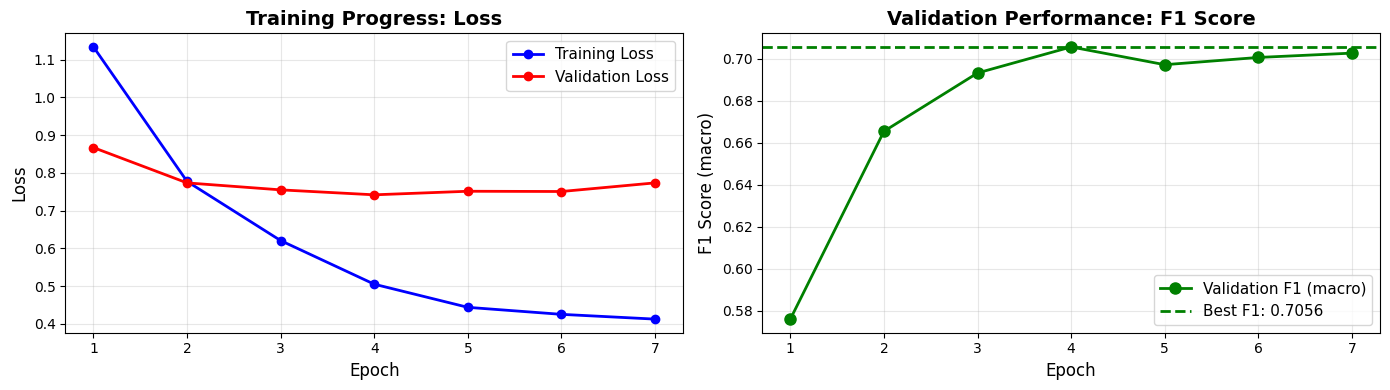

Training progress plot saved as "training_progress.png"


In [10]:
# Visualization of training progress
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1: Training & Validation Loss
axes[0].plot(range(1, len(all_train_losses) + 1), all_train_losses, 'b-o', label='Training Loss', linewidth=2)
axes[0].plot(range(1, len(all_val_losses) + 1), all_val_losses, 'r-o', label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training Progress: Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: Validation F1 Score
axes[1].plot(range(1, len(all_val_f1s) + 1), all_val_f1s, 'g-o', label='Validation F1 (macro)', linewidth=2, markersize=8)
axes[1].axhline(y=best_val_f1, color='g', linestyle='--', label=f'Best F1: {best_val_f1:.4f}', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('F1 Score (macro)', fontsize=12)
axes[1].set_title('Validation Performance: F1 Score', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_progress.png', dpi=100, bbox_inches='tight')
plt.show()

print('Training progress plot saved as "training_progress.png"')


PER-CLASS PERFORMANCE (Test Set)

              precision    recall  f1-score   support

    Abstract     0.7511    0.7926    0.7713       217
         Cgs     0.7674    0.6000    0.6735        55
  Children's     0.6941    0.7152    0.7045       165
      Family     0.6368    0.6279    0.6323       430
       Party     0.5638    0.5915    0.5773       142
    Strategy     0.7243    0.6667    0.6943       327
    Thematic     0.6784    0.6471    0.6624       238
         War     0.9172    0.9621    0.9391       633

    accuracy                         0.7512      2207
   macro avg     0.7166    0.7004    0.7068      2207
weighted avg     0.7487    0.7512    0.7493      2207



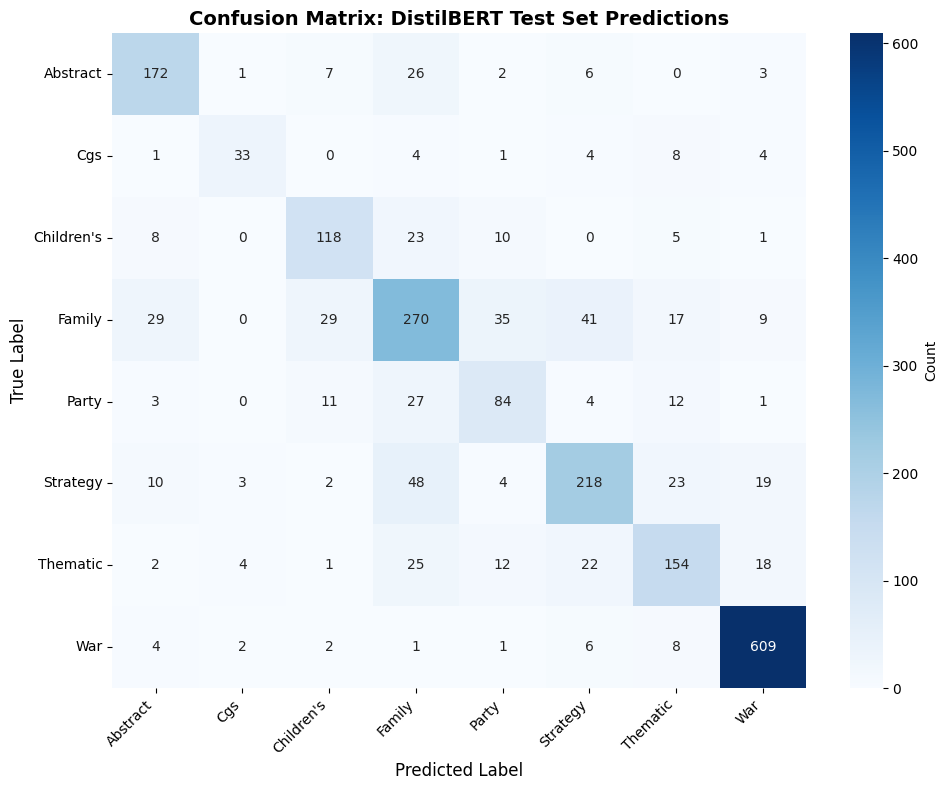

Confusion matrix plot saved as "confusion_matrix.png"

Per-class analysis complete


In [11]:
# Per-class performance analysis
from sklearn.metrics import classification_report, confusion_matrix

# Get test predictions
model.eval()
test_preds = []
test_labels_list = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        logits = model(input_ids, attention_mask)
        preds = torch.argmax(logits, dim=1)
        test_preds.extend(preds.cpu().numpy())
        test_labels_list.extend(labels.cpu().numpy())

# Classification report
print('\n' + '='*80)
print('PER-CLASS PERFORMANCE (Test Set)')
print('='*80)
print()
print(classification_report(test_labels_list, test_preds, target_names=label_names, digits=4))

# Confusion matrix visualization
cm = confusion_matrix(test_labels_list, test_preds)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, 
            yticklabels=label_names, cbar_kws={'label': 'Count'}, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix: DistilBERT Test Set Predictions', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

print('Confusion matrix plot saved as "confusion_matrix.png"')
print('\nPer-class analysis complete')

In [12]:
# Save model artifacts for future use
import json

# Save model
torch.save(model, 'distilbert_model_full.pt')

# Save tokenizer
tokenizer.save_pretrained('distilbert_tokenizer')

# Save metadata
metadata = {
    'model_type': 'DistilBERT',
    'num_classes': num_labels,
    'class_names': label_names.tolist(),
    'max_seq_length': 256,
    'test_accuracy': float(test_acc),
    'test_f1': float(test_f1),
    'test_precision': float(test_prec),
    'test_recall': float(test_recall),
    'epochs_trained': len(all_val_losses),
    'best_val_f1': float(best_val_f1)
}

with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('\n' + '='*80)
print('MODEL ARTIFACTS SAVED')
print('='*80)
print(f'   Model:          distilbert_model_full.pt')
print(f'   Tokenizer:      distilbert_tokenizer/')
print(f'   Metadata:       model_metadata.json')
print('='*80)

print('\n' + '='*80)
print('EXECUTIVE SUMMARY - PHASE 1 COMPLETE')
print('='*80)
print(f'''
MODEL: DistilBERT (Transformer-based Fine-tuning)
TASK: Multi-class Single-Label Classification (8 geek types)
DATASET: Board Game Geek descriptions (14,713 samples)

TRAINING CONFIGURATION:
├─ Architecture: DistilBERT + 2-layer head (384→384→8)
├─ Epochs: {len(all_val_losses)} (with early stopping)
├─ Batch Size: 32 (GPU optimized)
├─ Learning Rate: 2e-5 (AdamW + CosineAnnealing scheduler)
├─ Dropout: 0.2
└─ Device: {device}

TEST SET RESULTS:
├─ Accuracy: {test_acc:.4f}
├─ F1 Score (macro): {test_f1:.4f}
├─ Precision (macro): {test_prec:.4f}
└─ Recall (macro): {test_recall:.4f}

IMPROVEMENT OVER BASELINE:
└─ TF-IDF F1: {tfidf_val_f1:.4f} → DistilBERT F1: {test_f1:.4f} (↑{improvement:.1f}%)

OUTPUTS GENERATED:
├─ training_progress.png (loss & F1 curves)
├─ confusion_matrix.png (per-class predictions)
├─ distilbert_model_full.pt (full model)
├─ distilbert_tokenizer/ (tokenizer config)
└─ model_metadata.json (metadata)

Ready for Phase 2: Additional fine-tuning, ensemble, or deployment
''')
print('='*80)


MODEL ARTIFACTS SAVED
   Model:          distilbert_model_full.pt
   Tokenizer:      distilbert_tokenizer/
   Metadata:       model_metadata.json

EXECUTIVE SUMMARY - PHASE 1 COMPLETE

MODEL: DistilBERT (Transformer-based Fine-tuning)
TASK: Multi-class Single-Label Classification (8 geek types)
DATASET: Board Game Geek descriptions (14,713 samples)

TRAINING CONFIGURATION:
├─ Architecture: DistilBERT + 2-layer head (384→384→8)
├─ Epochs: 7 (with early stopping)
├─ Batch Size: 32 (GPU optimized)
├─ Learning Rate: 2e-5 (AdamW + CosineAnnealing scheduler)
├─ Dropout: 0.2
└─ Device: cuda

TEST SET RESULTS:
├─ Accuracy: 0.7512
├─ F1 Score (macro): 0.7068
├─ Precision (macro): 0.7166
└─ Recall (macro): 0.7004

IMPROVEMENT OVER BASELINE:
└─ TF-IDF F1: 0.6684 → DistilBERT F1: 0.7068 (↑5.7%)

OUTPUTS GENERATED:
├─ training_progress.png (loss & F1 curves)
├─ confusion_matrix.png (per-class predictions)
├─ distilbert_model_full.pt (full model)
├─ distilbert_tokenizer/ (tokenizer config)
└─ model